In [3]:
# Uncomment this if you dont have any of the packages necessary

# !pip install mne numpy seaborn pandas wfdb scipy

In [4]:
import numpy as np
import os
import mne
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, sosfiltfilt, sosfreqz, periodogram, welch

import warnings
warnings.filterwarnings("ignore")

## Read Data into memory

In [5]:
def read_annotations(subject,trial):
    file_path =  f"./files/eegmmidb/1.0.0/S{subject:03}/S{subject:03}R{trial:02}.edf"
    annotations = wfdb.rdann(file_path,'event')
    return annotations

In [6]:
# Data parameters
num_subjects = 109
# num_subjects = 1  # Loading all of our data would take 14 GB of memory, so we should just stick to a few subjects at a time
num_trials = 14
num_channels = 64
num_timepoints = 20000
subject_data = np.zeros((num_subjects,num_trials,num_channels,num_timepoints))

# Read all of our data into workspace
for subject in range(1, num_subjects+1):
    for trial in range(1,num_trials+1):
        file = Path("./") / "files" / "eegmmidb" / "1.0.0" / f"S{subject:03}" / f"S{subject:03}R{trial:02}.edf" # Reads files of all subjects dynamically
        try:
            with mne.io.read_raw_edf(file) as data:
                # Load data into subject_data np array
                raw_data = data.get_data()
                # Zero pad if this is a one-minute sample
                if raw_data.shape[1] != num_timepoints:
                    print(raw_data.shape)
                    subject_data[subject-1][trial-1] = np.pad(raw_data,((0,0),(0,num_timepoints - raw_data.shape[1])),'empty') # Add 9760 zero-padding to the right side of raw_data
                else:
                    subject_data[subject-1][trial-1] = raw_data
                # you can get the metadata included in the file and a list of all channels:
                info = data.info
                channels = data.ch_names
        except FileNotFoundError:
            print(f"{file} not found, skipping.")

Extracting EDF parameters from /Users/gustavoalburez/Desktop/COGS 189/cogs-189/files/eegmmidb/1.0.0/S001/S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 9760)
Extracting EDF parameters from /Users/gustavoalburez/Desktop/COGS 189/cogs-189/files/eegmmidb/1.0.0/S001/S001R02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 9760)
Extracting EDF parameters from /Users/gustavoalburez/Desktop/COGS 189/cogs-189/files/eegmmidb/1.0.0/S001/S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Users/gustavoalburez/Desktop/COGS 189/cogs-189/files/eegmmidb/1.0.0/S001/S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Users/gustavoalburez/Desktop/COGS 189/cogs-189/files/eegmmidb/1.0.0/S001/S001R05.edf...
EDF file detected
Setting channel info structu

In [7]:
subject_data.shape

(109, 14, 64, 20000)

In [8]:
info

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

In [9]:
fs = 160

In [10]:
channels

['Fc5.',
 'Fc3.',
 'Fc1.',
 'Fcz.',
 'Fc2.',
 'Fc4.',
 'Fc6.',
 'C5..',
 'C3..',
 'C1..',
 'Cz..',
 'C2..',
 'C4..',
 'C6..',
 'Cp5.',
 'Cp3.',
 'Cp1.',
 'Cpz.',
 'Cp2.',
 'Cp4.',
 'Cp6.',
 'Fp1.',
 'Fpz.',
 'Fp2.',
 'Af7.',
 'Af3.',
 'Afz.',
 'Af4.',
 'Af8.',
 'F7..',
 'F5..',
 'F3..',
 'F1..',
 'Fz..',
 'F2..',
 'F4..',
 'F6..',
 'F8..',
 'Ft7.',
 'Ft8.',
 'T7..',
 'T8..',
 'T9..',
 'T10.',
 'Tp7.',
 'Tp8.',
 'P7..',
 'P5..',
 'P3..',
 'P1..',
 'Pz..',
 'P2..',
 'P4..',
 'P6..',
 'P8..',
 'Po7.',
 'Po3.',
 'Poz.',
 'Po4.',
 'Po8.',
 'O1..',
 'Oz..',
 'O2..',
 'Iz..']

### Read the annotations file for event timesteps

In [11]:
import wfdb

# Specify the path to the .event file (without the extension)
# file_path = Path("./") / "files" / "eegmmidb" / "1.0.0" / f"S{subject:03}" / f"S{subject:03}R{trial:02}.edf.event" # Reads files of all subjects dynamically
subject = 1
trial = 3
file_path =  f"./files/eegmmidb/1.0.0/S{subject:03}/S{subject:03}R{trial:02}.edf"

# Read the annotation file
annotations = wfdb.rdann(file_path,'event')

# Print annotation sample times
print(annotations.sample)

# Print annotation labels
print(annotations.symbol)

[  672  1328  2000  2656  3328  3984  4656  5312  5984  6640  7312  7968
  8640  9296  9968 10624 11296 11952 12624 13280 13952 14608 15280 15936
 16608 17264 17936 18592 19264]
['"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"', '"']


### Filter the two trials, looking at motor, parietal, and frontal cortex

In [14]:
def butter_bandpass(lowcut, highcut, fs, order = 2):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        sos = butter(order, [low, high], analog = False, btype = 'band', output = 'sos')
        return sos

In [15]:
def plot_filtered_trial(subject_data, subject=1, trial=3, epoch_len=4, epoch_start=None,
                    motor_channels=['C4..','C3..','Cz..'],plot_title="Title"):
    """
    Display 3-plot of a given subject and trial using bandpass filter on Alpha, Beta, and Gamma ranges.
    For event colors, T0 is green, T1 is red, T2 is cyan.

    Args:
        subject_data (np.array): The dataset we are working with.
        subject (int): Which subject to look at (1-indexed).
        trial (int): Which subject to look at (1-indexed).
        epoch_len (int): How many epochs to look at, where one epoch is one target (T0,T1,T2).
        epoch_start (int): Which epoch to start at.
        motor_channels (list of str): Which channels to look at. Refer to the printed channels variable in cell above 
            for the list.
        plot_title (str): Title of the full figure.
        
    Returns: nothing
    """
   
    num_channels = len(motor_channels)
    
    df = pd.DataFrame(subject_data[subject-1][trial-1].T,columns=channels)  # Transpose to have 64 channels as columns

    # Create a figure and a set of subplots (e.g., 2 rows, 2 columns)
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12,12))
    
    # Read the annotation file
    file_path =  f"./files/eegmmidb/1.0.0/S{subject:03}/S{subject:03}R{trial:02}.edf"
    annotations = wfdb.rdann(file_path,'event')
    samples = annotations.sample
    notes = annotations.aux_note

    selected_channels = df[motor_channels]

    sos_alpha = butter_bandpass(8, 12, fs, order = 10)
    sos_beta = butter_bandpass(13, 30, fs, order = 10)
    sos_gamma = butter_bandpass(30, 79, fs, order = 10)

    alpha_df = selected_channels.apply(lambda x: sosfiltfilt(sos_alpha, x))
    beta_df = selected_channels.apply(lambda x: sosfiltfilt(sos_beta, x))
    gamma_df = selected_channels.apply(lambda x: sosfiltfilt(sos_gamma, x))

    sns.lineplot(data=alpha_df,ax=axes[0])
    sns.lineplot(data=beta_df,ax=axes[1])
    sns.lineplot(data=gamma_df,ax=axes[2])

    titles = ['Alpha (8-12 Hz)','Beta (13-30 Hz)','Gamma (30-79 Hz)']

    for sample, note in zip(samples,notes):        
        if 'T0' in note:
            color = 'g'
        elif 'T1' in note:
            color = 'r'
        elif 'T2' in note:
            color = 'c'
        else:
            color = 'y'

        for i in range(3):
            if epoch_start is None or type(epoch_start) is not int:
                axes[i].set_xlim(0, samples[epoch_len-1]+20)
            else:
                axes[i].set_xlim(annotations.sample[epoch_start-1]-20, annotations.sample[epoch_start + epoch_len - 1]+20)
            axes[i].axvline(x=sample, color=color, linestyle='--', label=f't = {x}')
            axes[i].set_title(titles[i])

    plt.suptitle(plot_title, fontsize=16)
    plt.xlabel("Timesteps")
    plt.ylabel("Amplitude")
    plt.tight_layout()  # Adjust spacing between subplots
    plt.show()

In [31]:
def format_data(df, subject, selected_channels='all', filter_bands=(8,12)):  # TODO filter alpha and beta bandpass
    """
    Format training/testing data into a 2d array of size (E, SxC), where S is how many samples there are in 
    one event (+1 since the label is at index 0), C is the number of channels, and E is the number of 
    non-resting events. Each E will correspond to one sample for the SVM.
    
    Inputs:
        df (pd.DataFrame): The full dataframe that includes all data for a single subject.
        subject (int): Which subject the data belongs to.
        selected_channels (optional, list or str): Which EEG channels to look at. Defaults to 'all'
        filter_bands (optional, tuple): The passbands for the filter. Defaults to the alpha band (8-12 Hz).
    
    Returns: 
        formatted_data (np.array): The formatted data, in size (E, SxC).
        labels (list): The labels with -1 for imaginary and 1 for real movements.
    """
    df_list = []
    if selected_channels == 'all':
        selected_channels = channels  # Use channels global var for all channel selection
        
    for trial in df:
        df = pd.DataFrame(trial.T,columns=channels)
        df_list.append(df)

    time_between_codes = 4
    fs = 160
    samples_between_codes = fs*time_between_codes

    imaginary_vs_real = {}
    for i in range(3,15):
        if i % 2 == 1:
            imaginary_vs_real[i] = 'real'
        else:
            imaginary_vs_real[i] = 'imaginary'

    trial_iter = 1
    formatted_data = None
    labels = []
    
    for trial in df_list:
        try:
            # Label 1 as a real trial, 0 as imaginary trial
            if 'real' in imaginary_vs_real[trial_iter]:
                label = 1
            elif 'imaginary' in imaginary_vs_real[trial_iter]: 
                label = -1
            else:
                continue  # Skip the baselines, TODO check if we should use baselines somehow
        except KeyError:
#             print('Key',trial_iter,'not detected, skipping...')
            trial_iter += 1
            continue

        annotations = read_annotations(subject,trial_iter)
        events = annotations.sample
        codes = annotations.aux_note

    #     T0 = [(sample,aux_note) for (sample,aux_note) in zip(events,codes) if 'T0' in aux_note]
        T1 = [(sample,aux_note) for (sample,aux_note) in zip(events,codes) if 'T1' in aux_note]
        T2 = [(sample,aux_note) for (sample,aux_note) in zip(events,codes) if 'T2' in aux_note]

        # For given trial, extract T1 and T2 events, then format them for output
        
        for event,_ in T1:  # samples x channels x epochs (each event/epoch gets 1 row)
            new_data = trial[event:event+samples_between_codes][selected_channels]  # samples x channels
            output_data = np.array(new_data)
            sz_1,sz_2 = output_data.shape
            output_data = np.reshape(output_data,(sz_1,sz_2,1))  # Turn into 3d array
        
            labels.append(label)

            if formatted_data is None:
                formatted_data = output_data
            else:
                formatted_data = np.concatenate([formatted_data, output_data],axis=2)
                
        for event,_ in T2:  # samples x channels x epochs (each event/epoch gets 1 row)
            new_data = trial[event:event+samples_between_codes][selected_channels]  # samples x channels
            output_data = np.array(new_data)
            sz_1,sz_2 = output_data.shape
            output_data = np.reshape(output_data,(sz_1,sz_2,1))  # Turn into 3d array
        
            labels.append(label)

            if formatted_data is None:
                formatted_data = output_data
            else:
                formatted_data = np.concatenate([formatted_data, output_data],axis=2)

        trial_iter += 1
    
    # Currently shaped (S,C,E), reshape to (E, SxC)
    S,C,E = formatted_data.shape
    return np.reshape(formatted_data,(E,S*C)), labels

Text(0.5, 1.0, 'Label: 1')

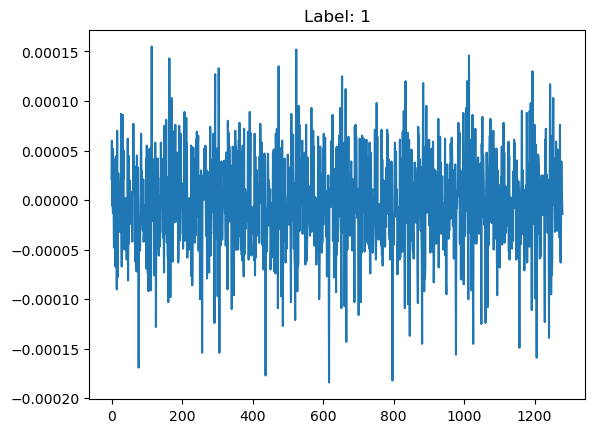

In [32]:
subject = 1

individual_data = subject_data[subject-1]

selected_channels = ['Cp3.','Cp4.']
output, labels = format_data(individual_data, subject, selected_channels=selected_channels, filter_bands=(8,12))

n = 1
sns.lineplot(output[n,:])
plt.title(f"Label: {labels[n]}")
# plt.legend(selected_channels)

# Band Power Between trials

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sosfiltfilt, welch

def compute_band_power(segment, fs, lowcut, highcut):
    """
    Compute the average power in a given frequency band for each channel in the segment.
    
    Args:
        segment: np.array of shape (channels, samples)
        fs: sampling frequency (Hz)
        lowcut: lower bound of the frequency band (Hz)
        highcut: upper bound of the frequency band (Hz)
    
    Returns:
        band_power: 1D np.array containing the mean power for each channel.
    """
    # Use the butter_bandpass function from your current code.
    sos = butter_bandpass(lowcut, highcut, fs, order=2)
    filtered = sosfiltfilt(sos, segment, axis=1)
    f, Pxx = welch(filtered, fs=fs, nperseg=fs*2, axis=1)
    band_power = np.mean(Pxx, axis=1)
    return band_power

def compute_trial_band_power(eeg_data, fs, region_channels, band):
    """
    Compute the average band power for the entire trial.
    
    Args:
        eeg_data: np.array of shape (channels, samples) for a single trial.
        fs: sampling frequency.
        region_channels: list of channel names (e.g., ['C4..','C3..','Cz..']).
        band: tuple (lowcut, highcut) defining the frequency band.
    
    Returns:
        avg_power: scalar value representing the average band power (averaged across specified channels).
    """
    # Get indices for the region channels.
    channel_indices = [channels.index(ch) for ch in region_channels]
    data = eeg_data[np.array(channel_indices), :]  # select only the channels of interest
    band_power = compute_band_power(data, fs, band[0], band[1])
    avg_power = np.mean(band_power)  # average across channels
    return avg_power

def compute_condition_band_power(trial_numbers, subject, region_channels, band, fs):
    """
    Process a list of trials (for a given condition) and compute the average band power 
    (over the entire trial) for each trial. Returns a list of trial values.
    
    Args:
        trial_numbers: list of trial numbers (1-indexed) for the condition.
        subject: subject number (1-indexed).
        region_channels: list of channel names (e.g., ['C4..','C3..','Cz..']).
        band: tuple (lowcut, highcut) defining the frequency band.
        fs: sampling frequency.
        
    Returns:
        trial_values: list of average band power values, one per trial.
    """
    trial_values = []
    for trial in trial_numbers:
        trial_idx = trial - 1  # convert from 1-indexed to 0-indexed
        eeg_trial = subject_data[subject-1][trial_idx]  # shape: (channels, samples)
        value = compute_trial_band_power(eeg_trial, fs, region_channels, band)
        trial_values.append(value)
    return trial_values


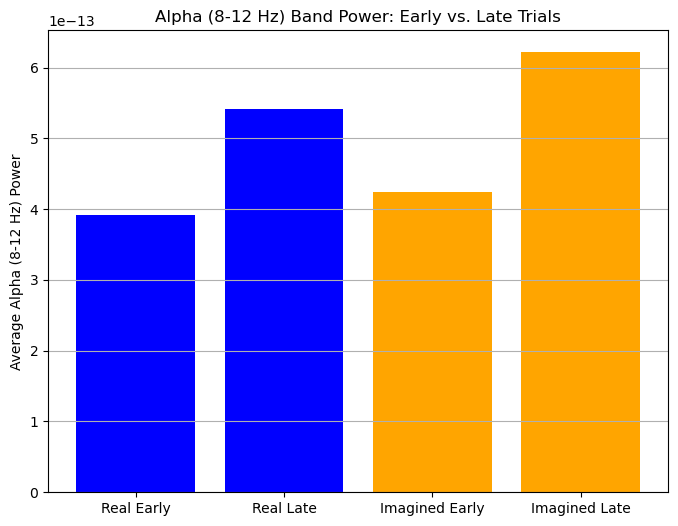

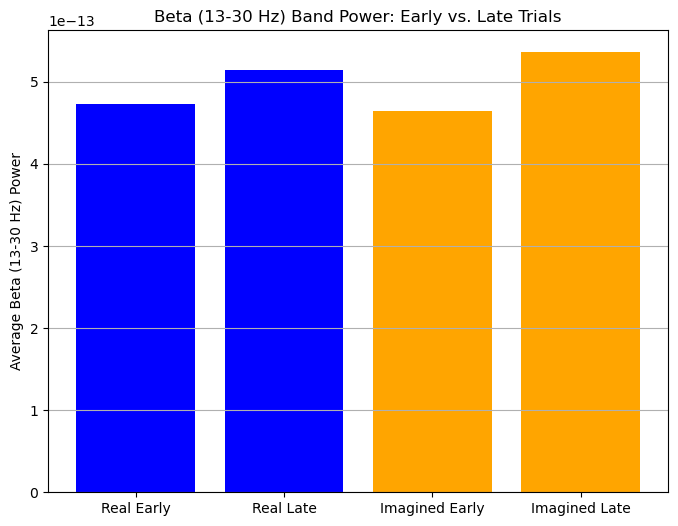

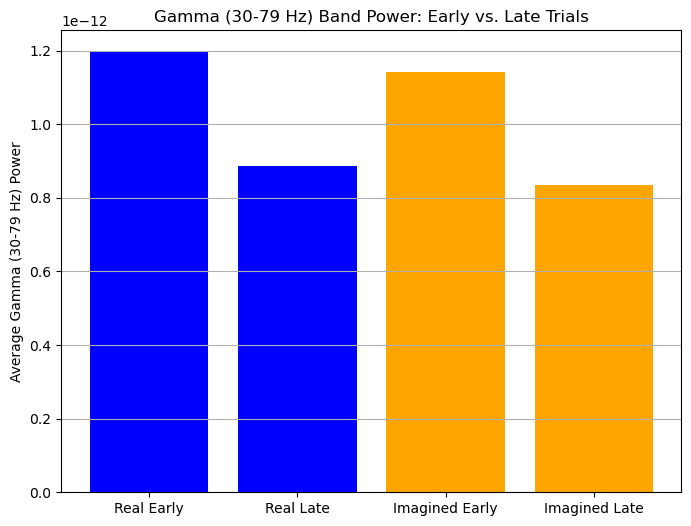

In [ ]:
def compute_all_subjects_condition_band(trial_numbers, subjects, region_channels, band, fs):
    """
    For a given condition, compute the trial-level band power for each subject
    and then average these values across subjects.
    
    Args:
        trial_numbers: list of trial numbers (1-indexed) for the condition.
        subjects: list of subject numbers (1-indexed).
        region_channels: list of channel names.
        band: tuple (lowcut, highcut) for the frequency band.
        fs: sampling frequency.
        
    Returns:
        group_avg: numpy array of shape (n_trials,) containing the average band power for each trial, averaged across subjects.
    """
    all_values = []
    for subj in subjects:
        trial_values = compute_condition_band_power(trial_numbers, subj, region_channels, band, fs)
        all_values.append(trial_values)
    all_values = np.array(all_values)  # shape: (n_subjects, n_trials)
    group_avg = np.mean(all_values, axis=0)
    return group_avg

# Define trial groups for between-trial analysis.
real_early = [3, 5, 7]
real_late = [9, 11, 13]
imagined_early = [4, 6, 8]
imagined_late = [10, 12, 14]

# Define the list of subjects (assuming num_subjects is defined).
subjects = list(range(1, num_subjects+1))

region_channels = ['C4..', 'C3..', 'Cz..']
alpha_band = (8, 12)
beta_band  = (13, 30)
gamma_band = (30, 79)

# Compute group averages for each trial group.
real_early_alpha = compute_all_subjects_condition_band(real_early, subjects, region_channels, alpha_band, fs)
real_late_alpha = compute_all_subjects_condition_band(real_late, subjects, region_channels, alpha_band, fs)
imagined_early_alpha = compute_all_subjects_condition_band(imagined_early, subjects, region_channels, alpha_band, fs)
imagined_late_alpha = compute_all_subjects_condition_band(imagined_late, subjects, region_channels, alpha_band, fs)

real_early_beta = compute_all_subjects_condition_band(real_early, subjects, region_channels, beta_band, fs)
real_late_beta = compute_all_subjects_condition_band(real_late, subjects, region_channels, beta_band, fs)
imagined_early_beta = compute_all_subjects_condition_band(imagined_early, subjects, region_channels, beta_band, fs)
imagined_late_beta = compute_all_subjects_condition_band(imagined_late, subjects, region_channels, beta_band, fs)

real_early_gamma = compute_all_subjects_condition_band(real_early, subjects, region_channels, gamma_band, fs)
real_late_gamma = compute_all_subjects_condition_band(real_late, subjects, region_channels, gamma_band, fs)
imagined_early_gamma = compute_all_subjects_condition_band(imagined_early, subjects, region_channels, gamma_band, fs)
imagined_late_gamma = compute_all_subjects_condition_band(imagined_late, subjects, region_channels, gamma_band, fs)

def plot_band_bar_graph(real_early, real_late, imagined_early, imagined_late, band_name):
    """
    Plot a grouped bar graph comparing early vs. late trials for real and imagined conditions.
    """
    x_labels = ['Real Early', 'Real Late', 'Imagined Early', 'Imagined Late']
    values = [np.mean(real_early), np.mean(real_late), np.mean(imagined_early), np.mean(imagined_late)]
    # For error bars, you could compute standard errors if desired; here we plot only the means.
    x = np.arange(len(x_labels))
    plt.figure(figsize=(8,6))
    bars = plt.bar(x, values, color=['blue','blue','orange','orange'])
    plt.xticks(x, x_labels)
    plt.ylabel(f'Average {band_name} Power')
    plt.title(f'{band_name} Band Power: Early vs. Late Trials')
    plt.grid(axis='y')
    plt.show()

# Plot bar graphs for each band.
plot_band_bar_graph(real_early_alpha, real_late_alpha, imagined_early_alpha, imagined_late_alpha, "Alpha (8-12 Hz)")
plot_band_bar_graph(real_early_beta, real_late_beta, imagined_early_beta, imagined_late_beta, "Beta (13-30 Hz)")
plot_band_bar_graph(real_early_gamma, real_late_gamma, imagined_early_gamma, imagined_late_gamma, "Gamma (30-79 Hz)")


In [55]:
from scipy.stats import ttest_rel

def perform_stat_tests(trial_group_early, trial_group_late, band, fs, region_channels, subjects):
    """
    For a given frequency band, compute per-subject average band power for early and late trials,
    then perform a paired t-test across subjects.
    
    Args:
        trial_group_early: list of trial numbers (1-indexed) for early trials.
        trial_group_late: list of trial numbers (1-indexed) for late trials.
        band: tuple (lowcut, highcut) for the frequency band.
        fs: sampling frequency.
        region_channels: list of channel names.
        subjects: list of subject numbers (1-indexed).
    
    Returns:
        t_stat, p_val: t-statistic and p-value from the paired t-test.
    """
    subject_early = {}
    subject_late = {}
    for subj in subjects:
        early_vals = compute_condition_band_power(trial_group_early, subj, region_channels, band, fs)
        late_vals = compute_condition_band_power(trial_group_late, subj, region_channels, band, fs)
        # Average the trial values for each subject.
        subject_early[subj] = np.mean(early_vals)
        subject_late[subj] = np.mean(late_vals)
    early_array = np.array([subject_early[s] for s in subjects])
    late_array = np.array([subject_late[s] for s in subjects])
    t_stat, p_val = ttest_rel(early_array, late_array)
    return t_stat, p_val

# Define the subject list.
subjects = list(range(1, num_subjects+1))

# Perform tests for each frequency band.
t_stat_alpha, p_val_alpha = perform_stat_tests(real_early, real_late, alpha_band, fs, region_channels, subjects)
t_stat_beta, p_val_beta = perform_stat_tests(real_early, real_late, beta_band, fs, region_channels, subjects)
t_stat_gamma, p_val_gamma = perform_stat_tests(real_early, real_late, gamma_band, fs, region_channels, subjects)

print("Real Movements Statistical Testing:")
print(f"Alpha: t-statistic = {t_stat_alpha:.4f}, p-value = {p_val_alpha:.4f}")
print(f"Beta: t-statistic = {t_stat_beta:.4f}, p-value = {p_val_beta:.4f}")
print(f"Gamma: t-statistic = {t_stat_gamma:.4f}, p-value = {p_val_gamma:.4f}")

# (You can similarly perform tests for imagined movements by replacing trial groups.)


Real Movements Statistical Testing:
Alpha: t-statistic = -1.7065, p-value = 0.0908
Beta: t-statistic = -0.7622, p-value = 0.4476
Gamma: t-statistic = 1.4228, p-value = 0.1577


In [60]:
from scipy.stats import ttest_rel
import numpy as np

def perform_stat_tests(trial_group_early, trial_group_late, band, fs, region_channels, subjects):
    """
    For a given frequency band, compute per-subject average band power for early and late trials,
    then perform a paired t-test across subjects.
    
    Args:
        trial_group_early: list of trial numbers (1-indexed) for early trials.
        trial_group_late: list of trial numbers (1-indexed) for late trials.
        band: tuple (lowcut, highcut) for the frequency band.
        fs: sampling frequency.
        region_channels: list of channel names.
        subjects: list of subject numbers (1-indexed).
    
    Returns:
        t_stat, p_val: t-statistic and p-value from the paired t-test.
    """
    subject_early = {}
    subject_late = {}
    for subj in subjects:
        early_vals = compute_condition_band_power(trial_group_early, subj, region_channels, band, fs)
        late_vals = compute_condition_band_power(trial_group_late, subj, region_channels, band, fs)
        # Average the trial values for each subject.
        subject_early[subj] = np.mean(early_vals)
        subject_late[subj] = np.mean(late_vals)
    early_array = np.array([subject_early[s] for s in subjects])
    late_array = np.array([subject_late[s] for s in subjects])
    t_stat, p_val = ttest_rel(early_array, late_array)
    return t_stat, p_val

# Define the subject list.
subjects = list(range(1, num_subjects+1))

# For Real Movements:
t_stat_alpha_real, p_val_alpha_real = perform_stat_tests(real_early, real_late, alpha_band, fs, region_channels, subjects)
t_stat_beta_real, p_val_beta_real = perform_stat_tests(real_early, real_late, beta_band, fs, region_channels, subjects)
t_stat_gamma_real, p_val_gamma_real = perform_stat_tests(real_early, real_late, gamma_band, fs, region_channels, subjects)

print("Real Movements Statistical Testing:")
print(f"Alpha: t-statistic = {t_stat_alpha_real:.4f}, p-value = {p_val_alpha_real:.4f}")
print(f"Beta: t-statistic = {t_stat_beta_real:.4f}, p-value = {p_val_beta_real:.4f}")
print(f"Gamma: t-statistic = {t_stat_gamma_real:.4f}, p-value = {p_val_gamma_real:.4f}")

# For Imagined Movements:
t_stat_alpha_imag, p_val_alpha_imag = perform_stat_tests(imagined_early, imagined_late, alpha_band, fs, region_channels, subjects)
t_stat_beta_imag, p_val_beta_imag = perform_stat_tests(imagined_early, imagined_late, beta_band, fs, region_channels, subjects)
t_stat_gamma_imag, p_val_gamma_imag = perform_stat_tests(imagined_early, imagined_late, gamma_band, fs, region_channels, subjects)

print("\nImagined Movements Statistical Testing:")
print(f"Alpha: t-statistic = {t_stat_alpha_imag:.4f}, p-value = {p_val_alpha_imag:.4f}")
print(f"Beta: t-statistic = {t_stat_beta_imag:.4f}, p-value = {p_val_beta_imag:.4f}")
print(f"Gamma: t-statistic = {t_stat_gamma_imag:.4f}, p-value = {p_val_gamma_imag:.4f}")


Real Movements Statistical Testing:
Alpha: t-statistic = -1.7065, p-value = 0.0908
Beta: t-statistic = -0.7622, p-value = 0.4476
Gamma: t-statistic = 1.4228, p-value = 0.1577

Imagined Movements Statistical Testing:
Alpha: t-statistic = -1.4459, p-value = 0.1511
Beta: t-statistic = -0.7453, p-value = 0.4577
Gamma: t-statistic = 1.3668, p-value = 0.1745


# Test between 2.0

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sosfiltfilt, welch

def compute_band_power(segment, fs, lowcut, highcut):
    """
    Compute the average power in a given frequency band for each channel in the segment.
    
    Args:
        segment: np.array of shape (channels, samples)
        fs: sampling frequency (Hz)
        lowcut: lower bound of the frequency band (Hz)
        highcut: upper bound of the frequency band (Hz)
    
    Returns:
        band_power: 1D np.array containing the mean power for each channel.
    """
    sos = butter_bandpass(lowcut, highcut, fs, order=2)  # assumes butter_bandpass is defined elsewhere
    filtered = sosfiltfilt(sos, segment, axis=1)
    f, Pxx = welch(filtered, fs=fs, nperseg=fs*2, axis=1)
    band_power = np.mean(Pxx, axis=1)
    return band_power

def compute_trial_band_power(eeg_data, fs, region_channels, band):
    """
    Compute the average band power for the entire trial.
    
    Args:
        eeg_data: np.array of shape (channels, samples) for a single trial.
        fs: sampling frequency.
        region_channels: list of channel names (e.g., ['C4..', 'C3..', 'Cz..']).
        band: tuple (lowcut, highcut) defining the frequency band.
    
    Returns:
        avg_power: scalar representing the average band power (averaged across specified channels).
    """
    channel_indices = [channels.index(ch) for ch in region_channels]
    data = eeg_data[np.array(channel_indices), :]  # select only the channels of interest
    band_power = compute_band_power(data, fs, band[0], band[1])
    avg_power = np.mean(band_power)
    return avg_power

def compute_condition_band_power(trial_numbers, subject, region_channels, band, fs):
    """
    Process a list of trials (for a given condition) and compute the average band power 
    (over the entire trial) for each trial.
    
    Args:
        trial_numbers: list of trial numbers (1-indexed) for the condition.
        subject: subject number (1-indexed).
        region_channels: list of channel names.
        band: tuple (lowcut, highcut) defining the frequency band.
        fs: sampling frequency.
        
    Returns:
        trial_values: list of average band power values, one per trial.
    """
    trial_values = []
    for trial in trial_numbers:
        trial_idx = trial - 1  # convert to 0-index
        eeg_trial = subject_data[subject-1][trial_idx]  # shape: (channels, samples)
        value = compute_trial_band_power(eeg_trial, fs, region_channels, band)
        trial_values.append(value)
    return trial_values


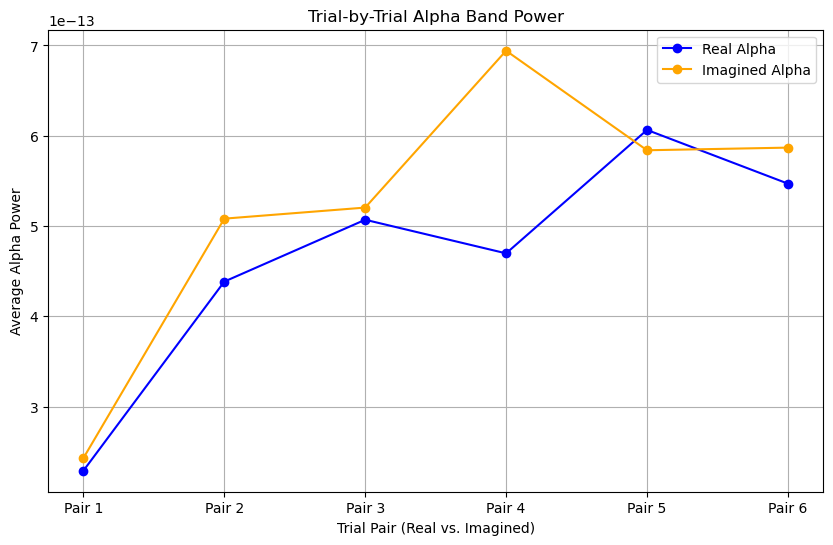

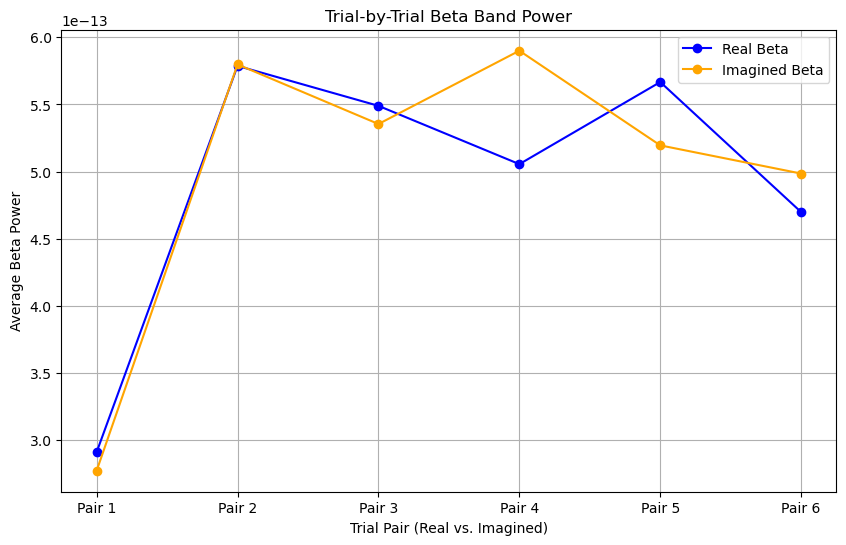

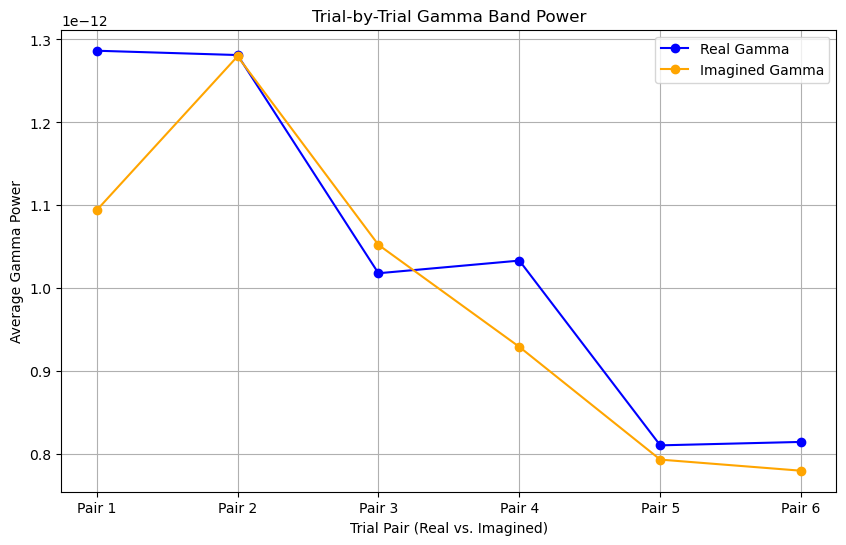

In [57]:
def compute_all_subjects_condition_band(trial_numbers, subjects, region_channels, band, fs):
    """
    For a given condition, compute the trial-level band power for each subject and then
    average these values across subjects.
    
    Args:
        trial_numbers: list of trial numbers (1-indexed) for the condition.
        subjects: list of subject numbers (1-indexed).
        region_channels: list of channel names.
        band: tuple (lowcut, highcut) for the frequency band.
        fs: sampling frequency.
        
    Returns:
        group_avg: numpy array of shape (n_trials,) with the average band power for each trial.
    """
    all_values = []
    for subj in subjects:
        trial_values = compute_condition_band_power(trial_numbers, subj, region_channels, band, fs)
        all_values.append(trial_values)
    all_values = np.array(all_values)  # shape: (n_subjects, n_trials)
    group_avg = np.mean(all_values, axis=0)
    return group_avg

# Define trial groups for between-trial analysis (paired real vs. imagined).
real_trials = [3, 5, 7, 9, 11, 13]
imagined_trials = [4, 6, 8, 10, 12, 14]

# Define the list of subjects (assuming num_subjects is defined).
subjects = list(range(1, num_subjects+1))

region_channels = ['C4..', 'C3..', 'Cz..']
alpha_band = (8, 12)
beta_band  = (13, 30)
gamma_band = (30, 79)

# Compute group averages for each trial.
real_alpha = compute_all_subjects_condition_band(real_trials, subjects, region_channels, alpha_band, fs)
imagined_alpha = compute_all_subjects_condition_band(imagined_trials, subjects, region_channels, alpha_band, fs)
real_beta = compute_all_subjects_condition_band(real_trials, subjects, region_channels, beta_band, fs)
imagined_beta = compute_all_subjects_condition_band(imagined_trials, subjects, region_channels, beta_band, fs)
real_gamma = compute_all_subjects_condition_band(real_trials, subjects, region_channels, gamma_band, fs)
imagined_gamma = compute_all_subjects_condition_band(imagined_trials, subjects, region_channels, gamma_band, fs)

# For visualization, we'll plot using the trial pair index (1 through 6).
x = np.arange(1, len(real_trials)+1)

# Plotting the trial-by-trial changes for each frequency band.
plt.figure(figsize=(10,6))
plt.plot(x, real_alpha, marker='o', linestyle='-', color='blue', label='Real Alpha')
plt.plot(x, imagined_alpha, marker='o', linestyle='-', color='orange', label='Imagined Alpha')
plt.xticks(x, [f"Pair {i}" for i in x])
plt.xlabel("Trial Pair (Real vs. Imagined)")
plt.ylabel("Average Alpha Power")
plt.title("Trial-by-Trial Alpha Band Power")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(x, real_beta, marker='o', linestyle='-', color='blue', label='Real Beta')
plt.plot(x, imagined_beta, marker='o', linestyle='-', color='orange', label='Imagined Beta')
plt.xticks(x, [f"Pair {i}" for i in x])
plt.xlabel("Trial Pair (Real vs. Imagined)")
plt.ylabel("Average Beta Power")
plt.title("Trial-by-Trial Beta Band Power")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(x, real_gamma, marker='o', linestyle='-', color='blue', label='Real Gamma')
plt.plot(x, imagined_gamma, marker='o', linestyle='-', color='orange', label='Imagined Gamma')
plt.xticks(x, [f"Pair {i}" for i in x])
plt.xlabel("Trial Pair (Real vs. Imagined)")
plt.ylabel("Average Gamma Power")
plt.title("Trial-by-Trial Gamma Band Power")
plt.legend()
plt.grid(True)
plt.show()


In [58]:
from scipy.stats import ttest_rel

def compute_subject_pair_values(subject, real_trial, imagined_trial, region_channels, band, fs):
    """
    For a given subject, compute the average band power for a real trial and its paired imagined trial.
    
    Args:
        subject: subject number (1-indexed)
        real_trial: trial number for real movement (1-indexed)
        imagined_trial: trial number for imagined movement (1-indexed)
        region_channels: list of channel names.
        band: tuple (lowcut, highcut) defining the frequency band.
        fs: sampling frequency.
        
    Returns:
        (real_value, imagined_value): tuple of average band power values for the real and imagined trial.
    """
    real_val = compute_trial_band_power(subject_data[subject-1][real_trial-1], fs, region_channels, band)
    imagined_val = compute_trial_band_power(subject_data[subject-1][imagined_trial-1], fs, region_channels, band)
    return real_val, imagined_val

# For each subject, compute paired values for each trial pair.
# Here, our pairs are: (3,4), (5,6), (7,8), (9,10), (11,12), (13,14)
n_pairs = len(real_trials)  # should be 6
subject_pair_values = {pair: {'real': [], 'imagined': []} for pair in range(n_pairs)}

for subj in subjects:
    for i, (r_trial, i_trial) in enumerate(zip(real_trials, imagined_trials)):
        r_val, i_val = compute_subject_pair_values(subj, r_trial, i_trial, region_channels, alpha_band, fs)
        subject_pair_values[i]['real'].append(r_val)
        subject_pair_values[i]['imagined'].append(i_val)

# Now perform paired t-tests for each pair across subjects.
print("Paired t-tests for Alpha Band (Real vs. Imagined) for each trial pair:")
for i in range(n_pairs):
    real_vals = np.array(subject_pair_values[i]['real'])
    imagined_vals = np.array(subject_pair_values[i]['imagined'])
    t_stat, p_val = ttest_rel(real_vals, imagined_vals)
    print(f"Pair {i+1} (Real trial {real_trials[i]} vs. Imagined trial {imagined_trials[i]}): t = {t_stat:.4f}, p = {p_val:.4f}")

# Similar procedures can be repeated for beta_band and gamma_band.


Paired t-tests for Alpha Band (Real vs. Imagined) for each trial pair:
Pair 1 (Real trial 3 vs. Imagined trial 4): t = -1.1961, p = 0.2343
Pair 2 (Real trial 5 vs. Imagined trial 6): t = -2.2661, p = 0.0254
Pair 3 (Real trial 7 vs. Imagined trial 8): t = -0.5069, p = 0.6132
Pair 4 (Real trial 9 vs. Imagined trial 10): t = -1.5095, p = 0.1341
Pair 5 (Real trial 11 vs. Imagined trial 12): t = 0.5087, p = 0.6120
Pair 6 (Real trial 13 vs. Imagined trial 14): t = -0.6319, p = 0.5288


In [59]:
from scipy.stats import ttest_rel
import numpy as np

# Define our bands in a dictionary.
bands = {
    "Alpha": (8, 12),
    "Beta": (13, 30),
    "Gamma": (30, 79)
}

# Assuming these variables are already defined:
# subjects: list of subject numbers (1-indexed)
# real_trials = [3, 5, 7, 9, 11, 13]
# imagined_trials = [4, 6, 8, 10, 12, 14]
# region_channels, fs, and compute_trial_band_power() are defined
# and compute_subject_pair_values() is as given in your snippet.

# We'll loop over each band.
n_pairs = len(real_trials)  # should be 6
for band_name, band in bands.items():
    # Dictionary to hold paired values for each trial pair.
    subject_pair_values = {pair: {'real': [], 'imagined': []} for pair in range(n_pairs)}
    
    for subj in subjects:
        for i, (r_trial, i_trial) in enumerate(zip(real_trials, imagined_trials)):
            r_val, i_val = compute_subject_pair_values(subj, r_trial, i_trial, region_channels, band, fs)
            subject_pair_values[i]['real'].append(r_val)
            subject_pair_values[i]['imagined'].append(i_val)
    
    print(f"\nPaired t-tests for {band_name} Band (Real vs. Imagined) for each trial pair:")
    for i in range(n_pairs):
        real_vals = np.array(subject_pair_values[i]['real'])
        imagined_vals = np.array(subject_pair_values[i]['imagined'])
        t_stat, p_val = ttest_rel(real_vals, imagined_vals)
        print(f"Pair {i+1} (Real trial {real_trials[i]} vs. Imagined trial {imagined_trials[i]}): t = {t_stat:.4f}, p = {p_val:.4f}")



Paired t-tests for Alpha Band (Real vs. Imagined) for each trial pair:
Pair 1 (Real trial 3 vs. Imagined trial 4): t = -1.1961, p = 0.2343
Pair 2 (Real trial 5 vs. Imagined trial 6): t = -2.2661, p = 0.0254
Pair 3 (Real trial 7 vs. Imagined trial 8): t = -0.5069, p = 0.6132
Pair 4 (Real trial 9 vs. Imagined trial 10): t = -1.5095, p = 0.1341
Pair 5 (Real trial 11 vs. Imagined trial 12): t = 0.5087, p = 0.6120
Pair 6 (Real trial 13 vs. Imagined trial 14): t = -0.6319, p = 0.5288

Paired t-tests for Beta Band (Real vs. Imagined) for each trial pair:
Pair 1 (Real trial 3 vs. Imagined trial 4): t = 0.5568, p = 0.5788
Pair 2 (Real trial 5 vs. Imagined trial 6): t = -0.0287, p = 0.9772
Pair 3 (Real trial 7 vs. Imagined trial 8): t = 0.3010, p = 0.7640
Pair 4 (Real trial 9 vs. Imagined trial 10): t = -0.9119, p = 0.3638
Pair 5 (Real trial 11 vs. Imagined trial 12): t = 1.1168, p = 0.2666
Pair 6 (Real trial 13 vs. Imagined trial 14): t = -0.5272, p = 0.5992

Paired t-tests for Gamma Band (Rea